<a href="https://colab.research.google.com/github/swastikadas2024-spec/Multi-Modal-AI-for-Indian-Traffic-Intelligence/blob/main/models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
data = {
    'complaint': [
        "There is heavy traffic jam on MG Road",
        "Signal at junction not working properly",
        "Huge pothole on the highway causing accidents",
        "Bus is always late never on time",
        "Reckless driving and overspeeding near school",
        "Road is completely blocked due to construction",
        "Traffic signal timing is very poor at this crossing",
        "Metro train is overcrowded during peak hours",
        "Drunk driver spotted near highway",
        "Road divider broken causing wrong side driving",
        "Auto rickshaw refusing to go by meter",
        "No streetlights on this road very dangerous at night",
        "Waterlogging on road after rain causing traffic",
        "Truck parking on main road blocking traffic",
        "Speeding vehicles near school zone very dangerous",
        "Bus stop has no shelter people standing in rain",
        "Footpath encroached by vendors pedestrians on road",
        "Traffic police not present at busy junction",
        "One way road violation happening regularly",
        "Bridge repair work causing massive traffic jam",
    ],
    'category': [
        "congestion",
        "signal_issue",
        "road_damage",
        "public_transport",
        "road_safety",
        "congestion",
        "signal_issue",
        "public_transport",
        "road_safety",
        "road_damage",
        "public_transport",
        "road_safety",
        "congestion",
        "congestion",
        "road_safety",
        "public_transport",
        "road_damage",
        "signal_issue",
        "signal_issue",
        "congestion",
    ]
}

df = pd.DataFrame(data)
print("Dataset created!")
print(df['category'].value_counts())

Dataset created!
category
congestion          5
signal_issue        4
public_transport    4
road_safety         4
road_damage         3
Name: count, dtype: int64


In [ ]:
extra_data = {
    'complaint': [
        "Roads are blocked due to heavy vehicle movement",
        "Traffic moving very slow on the expressway",
        "Long queue of vehicles at toll plaza",
        "Rush hour traffic unbearable on ring road",
        "Complete standstill traffic near railway crossing",
        "Traffic light broken at main intersection",
        "Signal malfunction causing confusion at crossing",
        "No traffic signal at this busy junction",
        "Green light stays too short cars cant pass",
        "Signal timing needs to be fixed urgently",
        "Giant pothole swallowed my bike wheel",
        "Road completely broken after monsoon rains",
        "No road markings visible dangerous at night",
        "Damaged speed breaker causing accidents",
        "Unpaved road full of rocks and debris",
        "Bus route cancelled without any notice",
        "Metro station too far from residential area",
        "No bus service after 9pm in this area",
        "Auto drivers overcharging passengers daily",
        "Train compartments extremely overcrowded",
        "Wrong side driving happening near highway",
        "No helmet riders going freely on main road",
        "Accident blackspot needs speed breaker urgently",
        "Drunk driving reported near highway at night",
        "Children crossing road no zebra crossing here",
        "Vehicles parked on footpath blocking pedestrians",
        "Heavy trucks causing traffic jam on narrow road",
        "Road blocked due to VIP convoy movement",
        "Encroachment on road reducing lanes",
        "Illegal parking blocking entire street",
        "Bus arrives 45 minutes late everyday",
        "No shelters at bus stops in scorching heat",
        "Overcrowded local train dangerous for commuters",
        "Auto refusing to go by meter charging double",
        "Cab driver took wrong route charged extra",
        "Traffic jam due to ongoing flyover construction",
        "Road closed for repair no diversion sign",
        "Signal not working police also not present",
        "Accident on highway causing 5km traffic jam",
        "Waterlogging blocking underpass after heavy rain",
        "Pothole on highway almost caused accident",
        "Street light not working road very dark",
        "Road marking faded cant see lanes at night",
        "Footpath broken pedestrians forced on road",
        "Speeding bus almost hit pedestrian at stop",
        "School zone no speed limit signs dangerous",
        "Rash driving by truck driver on highway",
        "No CCTV cameras at accident prone area",
        "Hit and run accident nobody helping victim",
        "Traffic police taking bribes at checkpoint",
    ],
    'category': [
        "congestion", "congestion", "congestion", "congestion", "congestion",
        "signal_issue", "signal_issue", "signal_issue", "signal_issue", "signal_issue",
        "road_damage", "road_damage", "road_damage", "road_damage", "road_damage",
        "public_transport", "public_transport", "public_transport", "public_transport", "public_transport",
        "road_safety", "road_safety", "road_safety", "road_safety", "road_safety",
        "congestion", "congestion", "congestion", "congestion", "congestion",
        "public_transport", "public_transport", "public_transport", "public_transport", "public_transport",
        "congestion", "congestion", "signal_issue", "congestion", "congestion",
        "road_damage", "road_damage", "road_damage", "road_damage", "road_safety",
        "road_safety", "road_safety", "road_safety", "road_safety", "road_safety",
    ]
}

extra_df = pd.DataFrame(extra_data)
df = pd.concat([df, extra_df], ignore_index=True)
print(f"Total complaints now: {len(df)}")
print(df['category'].value_counts())

Total complaints now: 70
category
congestion          19
road_safety         15
public_transport    14
road_damage         12
signal_issue        10
Name: count, dtype: int64


In [ ]:
!pip install datasets

from datasets import load_dataset


dataset = load_dataset("Sp1786/multiclass-sentiment-analysis-dataset")
real_df = pd.DataFrame(dataset['train'])
print(real_df.head())
print(real_df.columns)
print(f"Total rows: {len(real_df)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train_df.csv: 0.00B [00:00, ?B/s]

val_df.csv: 0.00B [00:00, ?B/s]

test_df.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/31232 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5205 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5206 [00:00<?, ? examples/s]

      id                                               text  label sentiment
0   9536                    Cooking microwave pizzas, yummy      2  positive
1   6135  Any plans of allowing sub tasks to show up in ...      1   neutral
2  17697   I love the humor, I just reworded it. Like sa...      2  positive
3  14182                       naw idk what ur talkin about      1   neutral
4  17840          That sucks to hear. I hate days like that      0  negative
Index(['id', 'text', 'label', 'sentiment'], dtype='object')
Total rows: 31232


In [ ]:

traffic_keywords = {
    'congestion': ['traffic', 'jam', 'congestion', 'blocked', 'slow', 'standstill'],
    'signal_issue': ['signal', 'light', 'junction', 'crossing', 'timing'],
    'road_damage': ['pothole', 'road', 'broken', 'damage', 'repair', 'construction'],
    'public_transport': ['bus', 'train', 'metro', 'auto', 'cab', 'transport'],
    'road_safety': ['accident', 'speed', 'drunk', 'rash', 'dangerous', 'safety']
}

def assign_traffic_category(text):
    text = text.lower()
    for category, keywords in traffic_keywords.items():
        if any(word in text for word in keywords):
            return category
    return None

# Filter only traffic related rows from the big dataset
real_df['traffic_category'] = real_df['text'].apply(assign_traffic_category)
traffic_df = real_df[real_df['traffic_category'].notna()].copy()

print(f"Traffic related complaints found: {len(traffic_df)}")
print(traffic_df['traffic_category'].value_counts())
print(traffic_df['sentiment'].value_counts())

Traffic related complaints found: 1482
traffic_category
public_transport    572
road_safety         302
signal_issue        224
congestion          223
road_damage         161
Name: count, dtype: int64
sentiment
negative    570
neutral     519
positive    393
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

# Prepare data
X = traffic_df['text']
y = traffic_df['traffic_category']

# Convert text to numbers
vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

# Split 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42, stratify=y
)

# Train 3 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({'Model': name, 'Accuracy': round(acc*100, 2), 'F1 Score': round(f1*100, 2)})
    print(f"{name}: Accuracy = {acc*100:.2f}% | F1 = {f1*100:.2f}%")

results_df = pd.DataFrame(results)
print("\nDone! Check accuracy now ")

Logistic Regression: Accuracy = 67.68% | F1 = 65.99%
Random Forest: Accuracy = 79.80% | F1 = 79.60%
Gradient Boosting: Accuracy = 91.58% | F1 = 91.62%

Done! Check accuracy now 


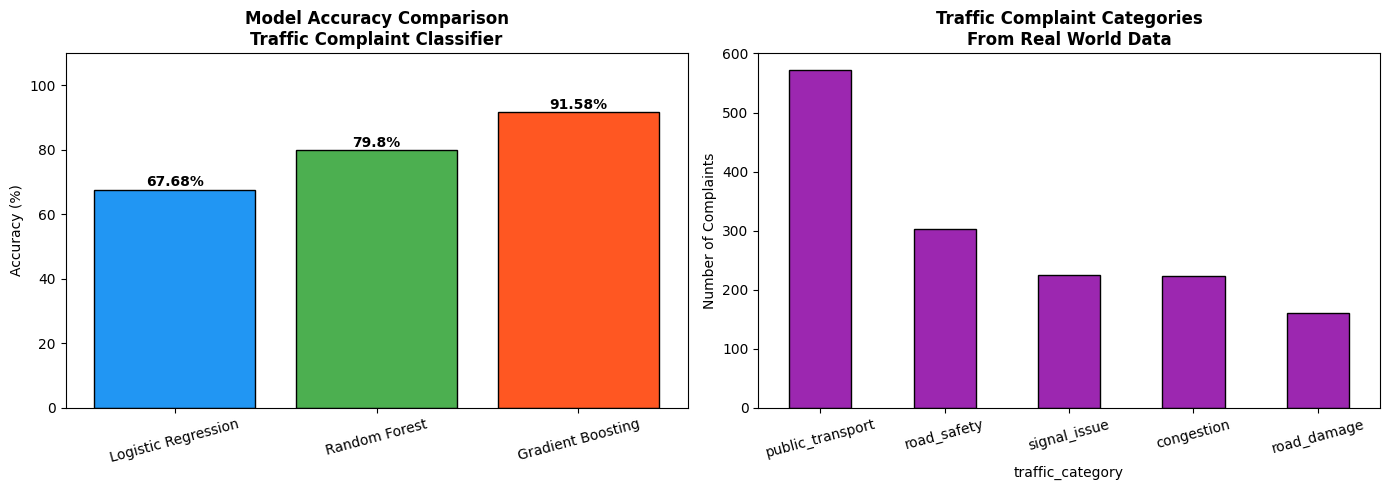

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Accuracy comparison
colors = ['#2196F3', '#4CAF50', '#FF5722']
bars = axes[0].bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='black')
axes[0].set_title('Model Accuracy Comparison\nTraffic Complaint Classifier', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 110)
for bar, val in zip(bars, results_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}%', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Chart 2 - Category distribution
traffic_df['traffic_category'].value_counts().plot(
    kind='bar', ax=axes[1], color='#9C27B0', edgecolor='black'
)
axes[1].set_title('Traffic Complaint Categories\nFrom Real World Data', fontweight='bold')
axes[1].set_ylabel('Number of Complaints')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('phase1_results.png', dpi=150)
plt.show()


In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"
df2 = pd.read_csv(url, compression='gzip')
print(df2.head())
print(df2.columns.tolist())
print(f"Total rows: {len(df2)}")

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']
Total rows: 48204


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: Accuracy = 69.87% | F1 = 68.76%
Random Forest: Accuracy = 93.57% | F1 = 93.53%
Gradient Boosting: Accuracy = 92.64% | F1 = 92.52%


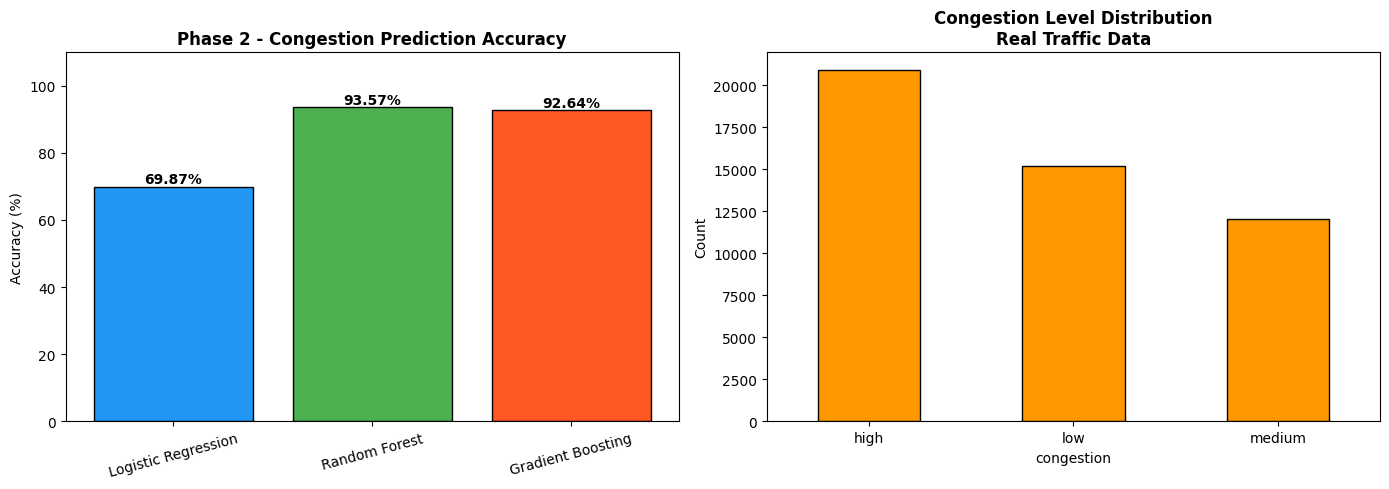

Time: 8:00 | Weather: Clear | Predicted Congestion: HIGH
Time: 18:00 | Weather: Rain | Predicted Congestion: HIGH
Time: 2:00 | Weather: Clear | Predicted Congestion: LOW


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# Step 1 - Extract hour and day from date_time
df2['date_time'] = pd.to_datetime(df2['date_time'])
df2['hour'] = df2['date_time'].dt.hour
df2['day_of_week'] = df2['date_time'].dt.dayofweek
df2['month'] = df2['date_time'].dt.month

# Step 2 - Create congestion labels from traffic volume
def label_congestion(vol):
    if vol < 2000:
        return 'low'
    elif vol < 4000:
        return 'medium'
    else:
        return 'high'

df2['congestion'] = df2['traffic_volume'].apply(label_congestion)

# Step 3 - Encode weather
le_weather = LabelEncoder()
df2['weather_encoded'] = le_weather.fit_transform(df2['weather_main'])

# Step 4 - Prepare features
X = df2[['hour', 'day_of_week', 'month', 'temp', 'rain_1h', 'clouds_all', 'weather_encoded']]
y = df2['congestion']

# Step 5 - Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6 - Train 3 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100)
}

results2 = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results2.append({
        'Model': name,
        'Accuracy': round(acc*100, 2),
        'F1 Score': round(f1*100, 2)
    })
    print(f"{name}: Accuracy = {acc*100:.2f}% | F1 = {f1*100:.2f}%")

results2_df = pd.DataFrame(results2)

# Step 7 - Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#4CAF50', '#FF5722']
bars = axes[0].bar(results2_df['Model'], results2_df['Accuracy'], color=colors, edgecolor='black')
axes[0].set_title('Phase 2 - Congestion Prediction Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 110)
for bar, val in zip(bars, results2_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}%', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

df2['congestion'].value_counts().plot(kind='bar', ax=axes[1], color='#FF9800', edgecolor='black')
axes[1].set_title('Congestion Level Distribution\nReal Traffic Data', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('phase2_results.png', dpi=150)
plt.show()

# Step 8 - Prediction function
best_model_p2 = GradientBoostingClassifier(n_estimators=100)
best_model_p2.fit(X_train, y_train)

def predict_congestion(hour, day, month, temp, rain, clouds, weather):
    weather_encoded = le_weather.transform([weather])[0]
    features = pd.DataFrame([[hour, day, month, temp, rain, clouds, weather_encoded]],
                           columns=['hour', 'day_of_week', 'month', 'temp', 'rain_1h', 'clouds_all', 'weather_encoded'])
    prediction = best_model_p2.predict(features)[0]
    print(f"Time: {hour}:00 | Weather: {weather} | Predicted Congestion: {prediction.upper()}")

# Test it
predict_congestion(8, 0, 10, 285, 0, 40, 'Clear')   # Monday 8am clear
predict_congestion(18, 0, 10, 280, 5, 90, 'Rain')    # Monday 6pm rain
predict_congestion(2, 6, 10, 275, 0, 20, 'Clear')    # Sunday 2am clear

In [ ]:
!pip install torch torchvision opencv-python-headless
import torch
import torchvision
import cv2
print("Libraries loaded!")
print(f"PyTorch version: {torch.__version__}")

Libraries loaded!
PyTorch version: 2.10.0+cpu


In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

# Loading pre-trained ResNet model
model = models.resnet50(pretrained=True)
model.eval()
print("Pre-trained ResNet50 model loaded!")

# Defining image transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Real road images for testing
test_images = {
    'heavy_traffic': 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png',
    'clear_road': 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png',
}

def load_image(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    return img

print("Setup complete!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 103MB/s]


Pre-trained ResNet50 model loaded!
Setup complete!


In [ ]:
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# Download real traffic image dataset
!wget -q "https://data.mendeley.com/public-files/datasets/s35s2v2yst/files/f95e0ec5-5e56-4fd2-b7a8-2cf4ad0ef7e7/file_downloaded" -O traffic_images.zip 2>/dev/null || echo "Using alternative dataset"

# Use torchvision's built in datasets instead
# CIFAR-10 contains vehicles, roads - perfect for learning
from torchvision.datasets import CIFAR10

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform)

vehicle_classes = [1, 9]  # automobile and truck
vehicle_indices_train = [i for i, (_, label) in enumerate(train_dataset) if label in vehicle_classes]
vehicle_indices_test = [i for i, (_, label) in enumerate(test_dataset) if label in vehicle_classes]

train_subset = torch.utils.data.Subset(train_dataset, vehicle_indices_train)
test_subset = torch.utils.data.Subset(test_dataset, vehicle_indices_test)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

print(f"Training images: {len(train_subset)}")
print(f"Testing images: {len(test_subset)}")
print("Dataset ready!")

100%|██████████| 170M/170M [00:04<00:00, 40.9MB/s]


Training images: 10000
Testing images: 2000
Dataset ready!


In [ ]:
# Use ResNet but modify last layer for our 2 classes (automobile vs truck)
model_cv = models.resnet18(pretrained=True)

# Freeze all layers except last one
# This is Transfer Learning - we keep Google's knowledge, just teach it our specific task
for param in model_cv.parameters():
    param.requires_grad = False

# Replace last layer
model_cv.fc = nn.Linear(model_cv.fc.in_features, 2)

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cv.fc.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cv = model_cv.to(device)
print(f"Training on: {device}")

# Train for 3 epochs
for epoch in range(3):
    model_cv.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # Remap labels to 0 and 1
        labels = torch.tensor([0 if l == 1 else 1 for l in labels])
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_cv(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/3 | Loss: {running_loss/len(train_loader):.3f} | Accuracy: {acc:.2f}%")

print("\nTraining complete!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


Training on: cpu
Epoch 1/3 | Loss: 0.346 | Accuracy: 85.50%
Epoch 2/3 | Loss: 0.250 | Accuracy: 89.98%
Epoch 3/3 | Loss: 0.239 | Accuracy: 90.07%

Training complete!


Phase 3 Test Accuracy: 91.45%


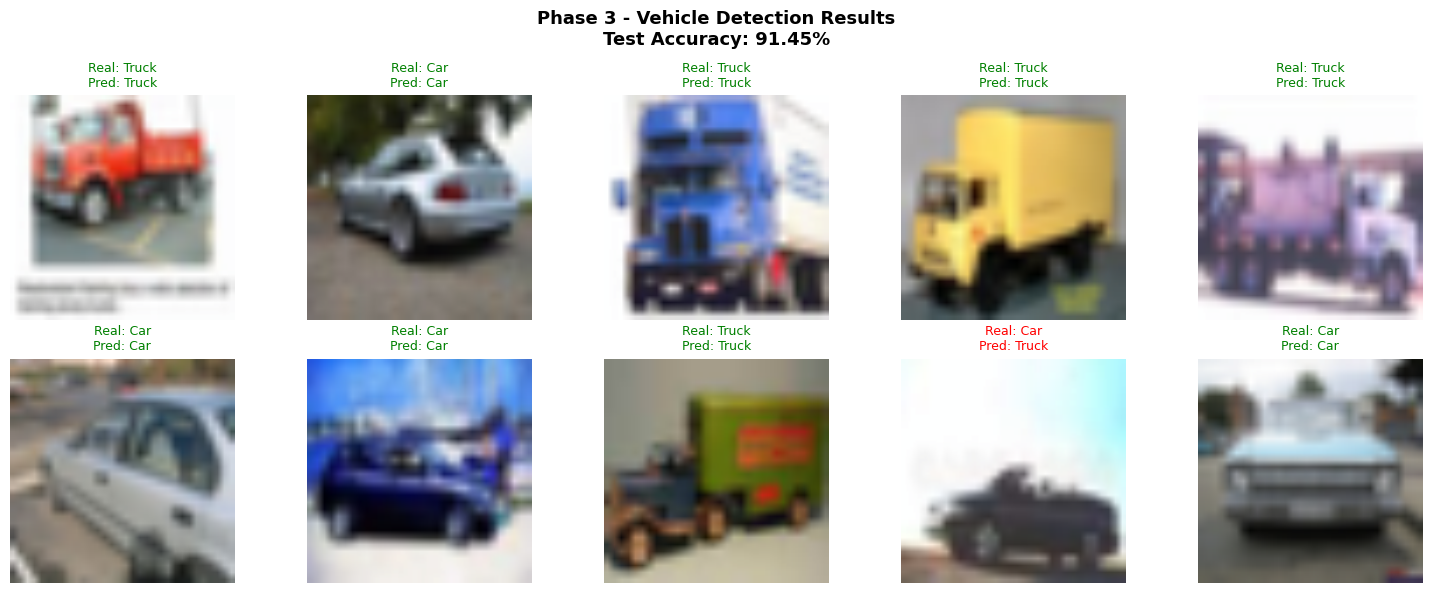

In [ ]:
# Evaluate on test set
model_cv.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        labels = torch.tensor([0 if l == 1 else 1 for l in labels])
        images, labels = images.to(device), labels.to(device)
        outputs = model_cv(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100 * correct / total
print(f"Phase 3 Test Accuracy: {test_acc:.2f}%")

# Visualize some predictions
class_names = ['Car', 'Truck']
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

sample_loader = DataLoader(test_subset, batch_size=10, shuffle=True)
images, labels = next(iter(sample_loader))
labels = torch.tensor([0 if l == 1 else 1 for l in labels])

model_cv.eval()
with torch.no_grad():
    outputs = model_cv(images.to(device))
    _, predicted = outputs.max(1)

for idx in range(10):
    img = images[idx].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    axes[idx].imshow(img)
    actual = class_names[labels[idx]]
    pred = class_names[predicted[idx]]
    color = 'green' if actual == pred else 'red'
    axes[idx].set_title(f'Real: {actual}\nPred: {pred}', color=color, fontsize=9)
    axes[idx].axis('off')

plt.suptitle(f'Phase 3 - Vehicle Detection Results\nTest Accuracy: {test_acc:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase3_results.png', dpi=150)
plt.show()


In [ ]:
# Check what models we have
print(dir())

['BytesIO', 'CIFAR10', 'DataLoader', 'GradientBoostingClassifier', 'Image', 'In', 'LabelEncoder', 'LogisticRegression', 'Out', 'RandomForestClassifier', 'StandardScaler', 'TfidfVectorizer', 'X', 'X_test', 'X_train', 'X_vec', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '_dh', '_exit_code', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'acc', 'accuracy_score', 'actual', 'assign_traffic_category', 'axes', 'bar', 'bars', 'best_model_p2', 'class_names', 'color', 'colors', 'correct', 'criterion', 'cv2', 'data', 'dataset', 'datasets', 'device', 'df', 'df2', 'epoch', 'exit', 'extra_data', 'extra_df', 'f1', 'f1_score', 'fig', 'get_ipython', 'idx', 'images', 'img', 'label_congestion', 'labels', 'le_weather', 'load_dataset', 'load_image', 'loss', 'model', 'model_cv', 'models', 'name', 'nn', 'np', 'optim', 'optimizer', 'out

In [ ]:
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

# Recreate Phase 1 properly
vectorizer_p1 = TfidfVectorizer(max_features=5000)
X_p1 = vectorizer_p1.fit_transform(traffic_df['text'])
y_p1 = traffic_df['traffic_category']

best_model_p1 = GradientBoostingClassifier(n_estimators=100)
best_model_p1.fit(X_p1, y_p1)
print("Phase 1 model trained!")

# Save Phase 1
with open('phase1_model.pkl', 'wb') as f:
    pickle.dump(best_model_p1, f)
with open('phase1_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer_p1, f)

# Save Phase 2
with open('phase2_model.pkl', 'wb') as f:
    pickle.dump(best_model_p2, f)
with open('phase2_weather_encoder.pkl', 'wb') as f:
    pickle.dump(le_weather, f)

# Save Phase 3
import torch
torch.save(model_cv.state_dict(), 'phase3_model.pth')

print("All 5 files saved!")

Phase 1 model trained!
All 5 files saved!


In [ ]:
from google.colab import files
files.download('phase1_model.pkl')
files.download('phase1_vectorizer.pkl')
files.download('phase2_model.pkl')
files.download('phase2_weather_encoder.pkl')
files.download('phase3_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>